****1. Understanding the Task****

Automated Essay Scoring (AES) is an NLP task where the aim is to predict how a human grader would score a written essay.
Each essay in our dataset has an associated prompt and a numeric score given by human raters.
The idea is to train a model that can learn patterns of strong vs. weak writing based on the language, structure, and vocabulary used.

In [54]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import cohen_kappa_score
from scipy.stats import pearsonr

****2. Loading the Data****

Let’s start by loading the ASAP 2.0 dataset.
We’ll take a quick look at its columns, number of records, and a few random samples to get a sense of what the essays look like and what type of scores we’re dealing with.

In [5]:
df = pd.read_csv("ASAP2_train_sourcetexts.csv")
print(df.shape)
df.head(3)

(24728, 14)


,essay_id,score,full_text,assignment,prompt_name,economically_disadvantaged,student_disability_status,ell_status,race_ethnicity,gender,source_text_1,source_text_2,source_text_3,source_text_4
0,AAAVUP14319000159574,4,The author suggests that studying Venus is wor...,"In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Economically disadvantaged,Identified as having disability,No,Black/African American,F,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN
1,AAAVUP14319000159542,2,NASA is fighting to be alble to to go to Venus...,"In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Not economically disadvantaged,Not identified as having disability,No,Hispanic/Latino,F,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN
2,AAAVUP14319000159461,3,"""The Evening Star"", is one of the brightest po...","In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Economically disadvantaged,Identified as having disability,No,White,M,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN


****3. Data Cleaning****

Before we analyze or train anything, the text needs to be cleaned.
Essays might contain extra spaces, inconsistent capitalization, or punctuation noise.
The idea here is not to “simplify” the language but to make sure the data is consistent and free of formatting junk that could distract the model.

In [7]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^a-z0-9\s]', '', text)
    return text.strip()

df['clean_text'] = df['full_text'].apply(clean_text)
df.dropna(subset=['score', 'clean_text'], inplace=True)

df['clean_text'].head(3)


0    the author suggests that studying venus is wor...
1    nasa is fighting to be alble to to go to venus...
2    the evening star is one of the brightest point...
Name: clean_text, dtype: object

****4. Exploring the Data (EDA)****

This part helps us understand what’s going on inside the dataset.
I’ll check how the scores are distributed, how long essays typically are, and whether certain prompts have noticeably different score ranges.
Visualizing these patterns helps build intuition before jumping into modeling.

In [9]:
#Checking basic info
print("Number of essays:", len(df))
print("Columns:", df.columns.tolist())

# Basic stats about the scores
print("\nScore summary:")
print(df['score'].describe())

# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())


Number of essays: 24728
Columns: ['essay_id', 'score', 'full_text', 'assignment', 'prompt_name', 'economically_disadvantaged', 'student_disability_status', 'ell_status', 'race_ethnicity', 'gender', 'source_text_1', 'source_text_2', 'source_text_3', 'source_text_4', 'clean_text']

Score summary:
count    24728.000000
mean         2.939987
std          1.035991
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max          6.000000
Name: score, dtype: float64

Missing values per column:
essay_id                          0
score                             0
full_text                         0
assignment                        0
prompt_name                       0
economically_disadvantaged     4005
student_disability_status      4005
ell_status                      442
race_ethnicity                    4
gender                            0
source_text_1                     0
source_text_2                 20723
source_text_3                 20723
sour

****4.1 Score Distribution****

This plot shows how essay scores are spread out.
It tells us if the dataset is balanced (lots of high and low scores) or skewed toward a particular range.

/Users/hassan/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


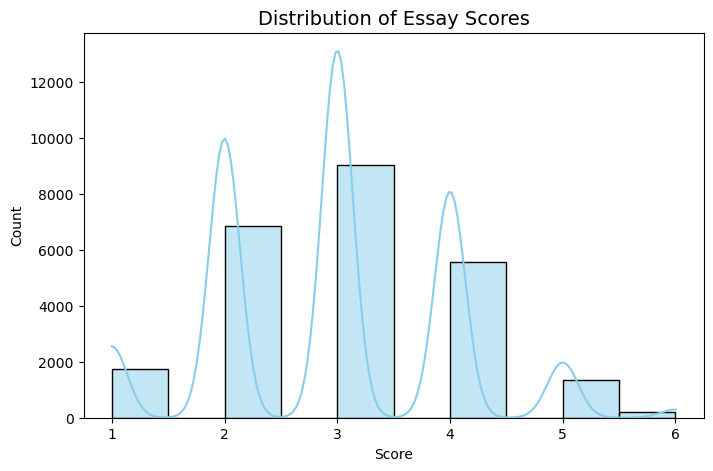

In [11]:
#Score Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['score'], bins=10, kde=True, color='skyblue')
plt.title("Distribution of Essay Scores", fontsize=14)
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()

****4.2 Essay Length Analysis and then vs. Score****

Longer essays might sometimes correlate with higher scores, but not always.
Let’s see if we can find any visible relationship between the length of an essay and the score it received.

/Users/hassan/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


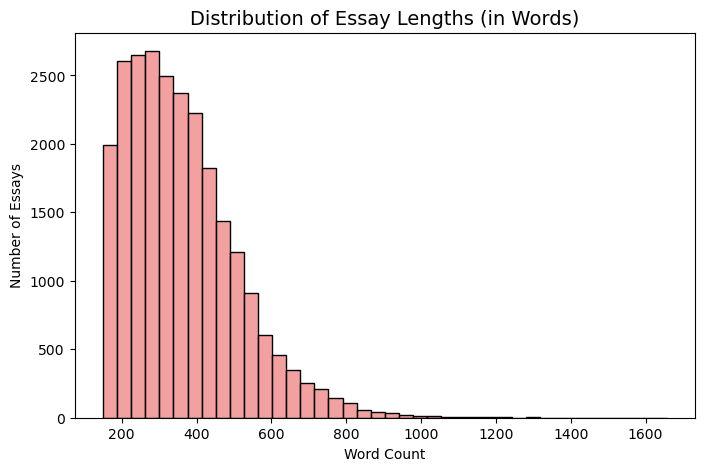

In [13]:
#Essay length analysis
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(8,5))
sns.histplot(df['word_count'], bins=40, color='lightcoral')
plt.title("Distribution of Essay Lengths (in Words)", fontsize=14)
plt.xlabel("Word Count")
plt.ylabel("Number of Essays")
plt.show()


In [14]:
#Check for correlation
corr = df[['word_count', 'score']].corr().iloc[0,1]
print(f"Correlation between essay length and score: {corr:.3f}")


Correlation between essay length and score: 0.708


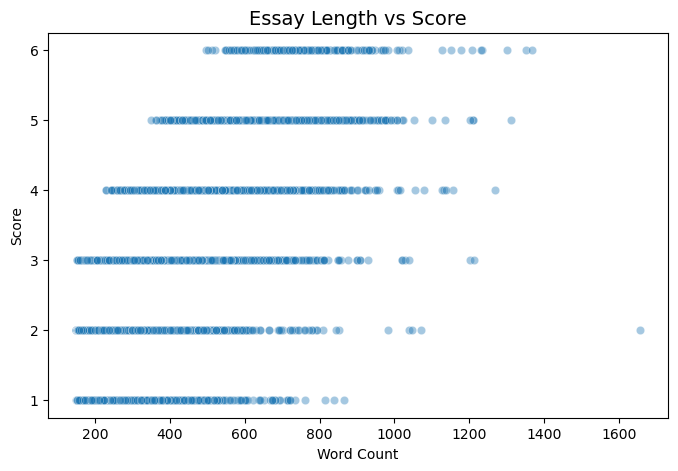

In [15]:
#Essay length vs Score (scatter plot)
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='word_count', y='score', alpha=0.4)
plt.title("Essay Length vs Score", fontsize=14)
plt.xlabel("Word Count")
plt.ylabel("Score")
plt.show()


****4.3 Prompt Frequency****

Each essay belongs to a prompt (a writing topic).
Checking how many essays appear per prompt helps us understand the diversity of topics in the dataset.

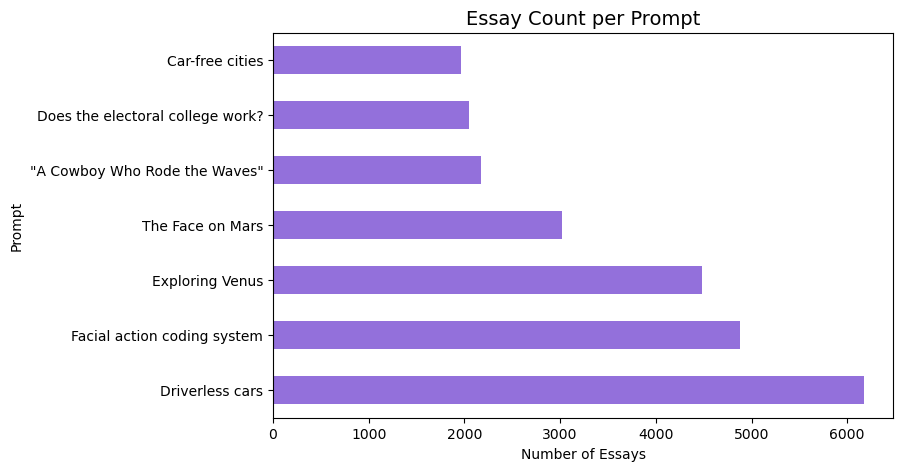

In [17]:
#Prompt-wise analysis
plt.figure(figsize=(8,5))
df['prompt_name'].value_counts().plot(kind='barh', color='mediumpurple')
plt.title("Essay Count per Prompt", fontsize=14)
plt.xlabel("Number of Essays")
plt.ylabel("Prompt")
plt.show()


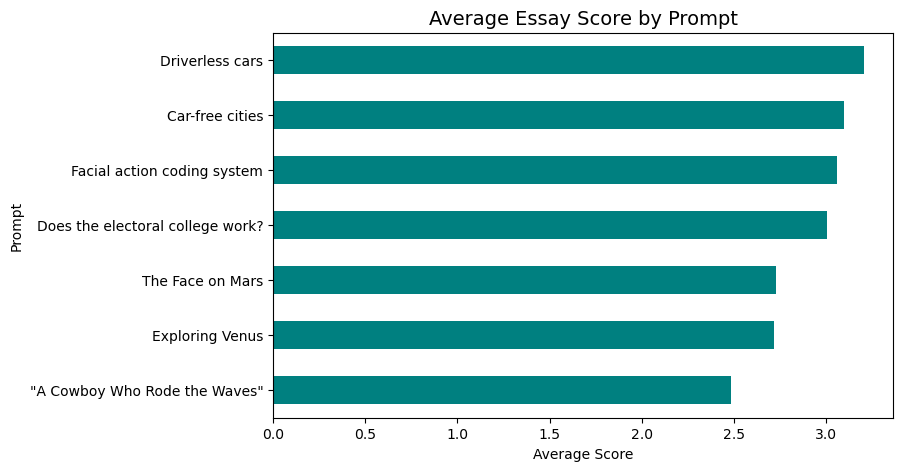

In [18]:
#Average score per prompt
prompt_means = df.groupby('prompt_name')['score'].mean().sort_values()
plt.figure(figsize=(8,5))
prompt_means.plot(kind='barh', color='teal')
plt.title("Average Essay Score by Prompt", fontsize=14)
plt.xlabel("Average Score")
plt.ylabel("Prompt")
plt.show()


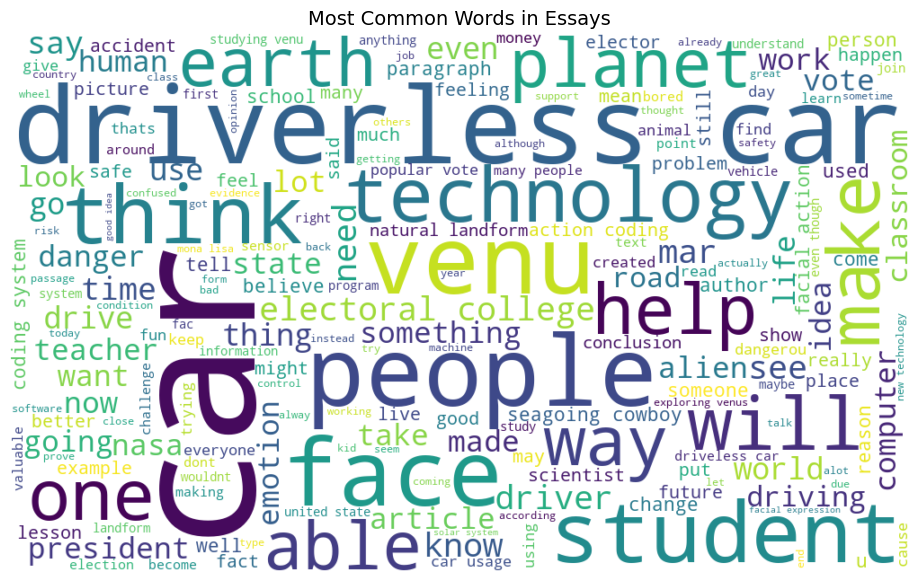

In [19]:
#Word Cloud (to visualise most common words)
text = " ".join(df['clean_text'])
wc = WordCloud(width=1000, height=600, background_color="white").generate(text)

plt.figure(figsize=(12,7))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Essays", fontsize=14)
plt.show()

****5. Turning Text into Features (TF-IDF)****

Machines don’t understand words directlywe need to convert essays into numerical form.
I’ll use TF-IDF (Term Frequency – Inverse Document Frequency), which gives higher weight to words that are unique and meaningful across essays.
This will give each essay a feature vector that can be fed into a regression model.

In [21]:
#Defining the vectorizer
vectorizer = TfidfVectorizer(
    max_features=5000,      #limiting vocabulary size (to prevent memory blow-up)
    ngram_range=(1, 2),     #including single words + short phrases (bigrams)
    stop_words='english'    #removing basic English stopwords
)

#Fitting on essays and transforming into numerical vectors
X = vectorizer.fit_transform(df['clean_text'])
y = df['score']

print("TF-IDF matrix shape:", X.shape)

TF-IDF matrix shape: (24728, 5000)


In [22]:
#Top TF-IDF words
feature_names = vectorizer.get_feature_names_out()
tfidf_means = np.asarray(X.mean(axis=0)).ravel()
top_idx = tfidf_means.argsort()[-20:][::-1]

top_features = [(feature_names[i], tfidf_means[i]) for i in top_idx]
pd.DataFrame(top_features, columns=['Word / Phrase', 'Average TF-IDF']).style.background_gradient(cmap='Blues')


,Word / Phrase,Average TF-IDF
0,cars,0.073668
1,venus,0.071621
2,car,0.062879
3,driverless,0.048606
4,people,0.039617
5,face,0.036576
6,driverless cars,0.033393
7,technology,0.029355
8,like,0.028433
9,students,0.027582


****6. Building a Simple Baseline Model****

For a first attempt, We are using XGB Classifier.
XGBoost (Extreme Gradient Boosting) is a powerful tree-based model that builds an ensemble of decision trees in a boosting framework. Each new tree focuses on correcting the mistakes of the previous ones, allowing the model to learn complex patterns in the data. It is fast, robust, and often achieves strong performance on structured text-feature tasks, making it a reliable choice for improving accuracy in essay scoring.

****6.1 Train-test split****
    
We’ll keep 20 % of essays aside for testing, so we can see how the model performs on unseen data.

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])


Train size: 19782
Test size: 4946


****6.2 Train the XGB Classifier model and make predictions****

In [28]:
# Adjusting y labels to start from 0
y_train_adjusted = y_train - 1
y_test_adjusted = y_test - 1

xgb_clf = XGBClassifier(n_estimators=100, max_depth=10, random_state=42)
xgb_clf.fit(X_train, y_train_adjusted)


y_pred_xgb = xgb_clf.predict(X_test)

# Adjusting predictions back to original labels (1-6)
y_pred_xgb_original = y_pred_xgb + 1


XGBoost Accuracy: 0.561


****7. Evaluating Model Performance and Visualizing****
    
After training, we’ll compare the predicted scores to the actual human scores.

I’ll use three metrics:

    1. Accuracy
    2. Confusion Matrix
    3. Classification Report: Precision, Recall and F1-Scores for each class

XGBoost Accuracy: 0.561


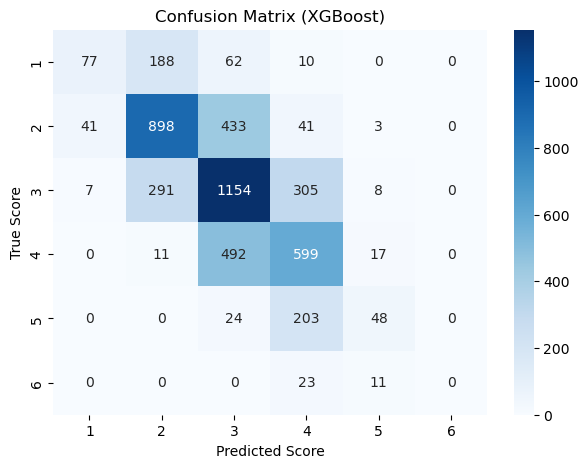


Classification Report:
              precision    recall  f1-score   support

           1       0.62      0.23      0.33       337
           2       0.65      0.63      0.64      1416
           3       0.53      0.65      0.59      1765
           4       0.51      0.54      0.52      1119
           5       0.55      0.17      0.27       275
           6       0.00      0.00      0.00        34

    accuracy                           0.56      4946
   macro avg       0.48      0.37      0.39      4946
weighted avg       0.56      0.56      0.55      4946



/Users/hassan/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/hassan/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/hassan/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


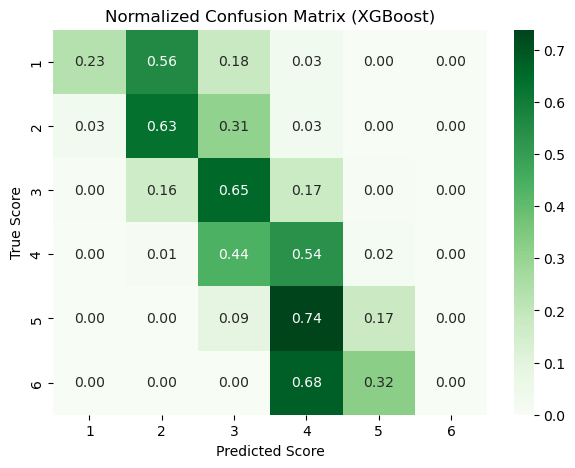

<Figure size 800x600 with 0 Axes>

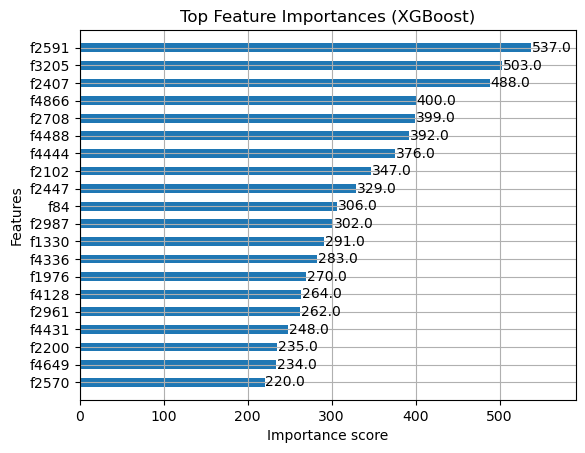


Quadratic Weighted Kappa (QWK): 0.677


In [56]:
# accuracy
accuracy = accuracy_score(y_test, y_pred_xgb_original)
print(f"XGBoost Accuracy: {accuracy:.3f}")

# conf. matrix
conf_matrix = confusion_matrix(y_test, y_pred_xgb_original)

plt.figure(figsize=(7,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=[1,2,3,4,5,6],
            yticklabels=[1,2,3,4,5,6])
plt.title("Confusion Matrix (XGBoost)")
plt.xlabel("Predicted Score")
plt.ylabel("True Score")
plt.show()

# classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb_original))

# normalized confusion matrix
conf_norm = confusion_matrix(y_test, y_pred_xgb_original, normalize='true')

plt.figure(figsize=(7,5))
sns.heatmap(conf_norm, annot=True, cmap='Greens', fmt='.2f',
            xticklabels=[1,2,3,4,5,6],
            yticklabels=[1,2,3,4,5,6])
plt.title("Normalized Confusion Matrix (XGBoost)")
plt.xlabel("Predicted Score")
plt.ylabel("True Score")
plt.show()

# feature importance plot
plt.figure(figsize=(8,6))
xgb.plot_importance(xgb_clf, max_num_features=20, height=0.5)
plt.title("Top Feature Importances (XGBoost)")
plt.show()

# quadratic weighted kappa 
qwk = cohen_kappa_score(y_test, y_pred_xgb_original, weights='quadratic')
print(f"\nQuadratic Weighted Kappa (QWK): {qwk:.3f}")

****8. Summary****

This notebook covered the basic groundwork for our Automated Essay Scoring project:

    - Cleaned and explored the ASAP 2.0 dataset
    - Built a quick TF-IDF + XGB Classifier Model
    - Evaluated performance using classification metrics 